In [18]:
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (confusion_matrix, classification_report,
roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay)

from tensorflow import keras

In [19]:
# Load test data
x_test = joblib.load("data/processed/x_test_deep.pkl")
y_test = joblib.load("data/processed/y_test_deep.pkl")
x_train = joblib.load("data/processed/x_train_deep.pkl")

In [26]:
# Load trained models
model_ann = keras.models.load_model("models/best_model_ann.keras")
autoencoder = keras.models.load_model("models/autoencoder.h5", compile=False)

In [27]:
# ANN Predictions
ann_pred_prob = model_ann.predict(x_test).ravel()
ensemble_score = ann_pred_prob
ensemble_pred = (ensemble_score >= 0.5).astype(int)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


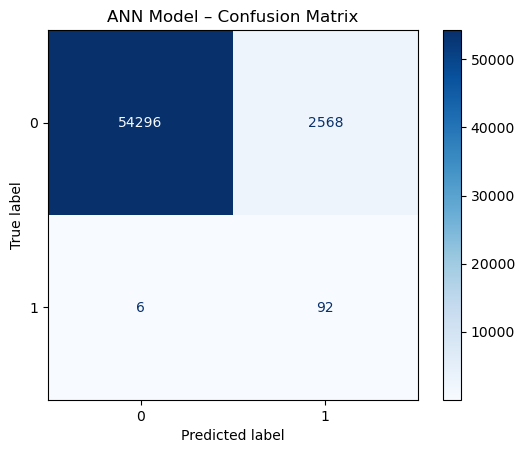

In [28]:
# Confusion Matrix
cm = confusion_matrix(y_test, ensemble_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("ANN Model – Confusion Matrix")
plt.show()

In [29]:
# Precision, Recall, F1-Score
print("=== Classification Report (ANN) ===")
print(classification_report(y_test, ensemble_pred, digits=6))

=== Classification Report (ANN) ===
              precision    recall  f1-score   support

           0   0.999890  0.954840  0.976845     56864
           1   0.034586  0.938776  0.066715        98

    accuracy                       0.954812     56962
   macro avg   0.517238  0.946808  0.521780     56962
weighted avg   0.998229  0.954812  0.975280     56962



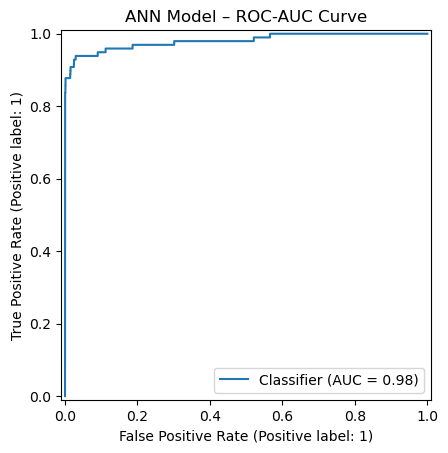

ROC-AUC Score: 0.9804085903494768


In [30]:
# ROC-AUC Curve
RocCurveDisplay.from_predictions(y_test, ensemble_score)
plt.title("ANN Model – ROC-AUC Curve")
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, ensemble_score))

In [31]:
# Autoencoder Threshold Analysis
x_test_pred = autoencoder.predict(x_test, batch_size=2048)
mse = np.mean(np.square(x_test - x_test_pred), axis=1)

percentiles = [95, 97, 98, 99]

for p in percentiles:
    thr = np.percentile(mse, p)
    pred = (mse > thr).astype(int)

    print(f"\n=== Autoencoder Threshold: {p}% ===")
    print(classification_report(y_test, pred, digits=6))

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step  

=== Autoencoder Threshold: 95% ===
              precision    recall  f1-score   support

           0   0.999815  0.951446  0.975031     56864
           1   0.030888  0.897959  0.059722        98

    accuracy                       0.951354     56962
   macro avg   0.515352  0.924702  0.517376     56962
weighted avg   0.998148  0.951354  0.973456     56962


=== Autoencoder Threshold: 97% ===
              precision    recall  f1-score   support

           0   0.999819  0.971493  0.985453     56864
           1   0.051492  0.897959  0.097399        98

    accuracy                       0.971367     56962
   macro avg   0.525656  0.934726  0.541426     56962
weighted avg   0.998187  0.971367  0.983925     56962


=== Autoencoder Threshold: 98% ===
              precision    recall  f1-score   support

           0   0.999785  0.981465  0.990540     56864
           1   0.075439  0.877551  0.138934        98

    accuracy                    

In [32]:
# AE + ANN Ensemble (Weighted)
mse_norm = (mse - mse.min()) / (mse.max() - mse.min())

weights = [0.3, 0.5, 0.7]

print("\n=== AE + ANN Ensemble Results ===")
for w in weights:
    ens_score = (w * mse_norm) + ((1 - w) * ann_pred_prob)
    ens_pred = (ens_score > 0.5).astype(int)

    roc = roc_auc_score(y_test, ens_score)
    print(f"AE weight = {w}, ANN weight = {1-w}, ROC-AUC = {roc:.6f}")


=== AE + ANN Ensemble Results ===
AE weight = 0.3, ANN weight = 0.7, ROC-AUC = 0.980608
AE weight = 0.5, ANN weight = 0.5, ROC-AUC = 0.980657
AE weight = 0.7, ANN weight = 0.30000000000000004, ROC-AUC = 0.980671


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


  0%|          | 0/30 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1318/1318 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

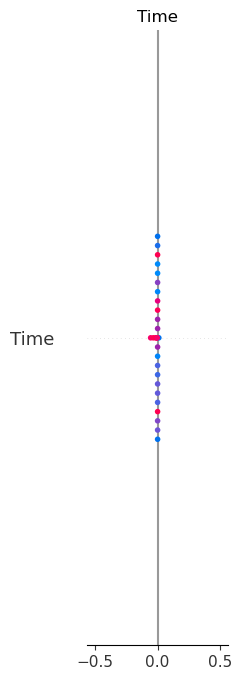

In [36]:
# SHAP Explainability for ANN
import shap

background = shap.kmeans(x_train, 20)

explainer = shap.KernelExplainer(model_ann.predict, background)
shap_values = explainer.shap_values(x_test[:30])

shap.summary_plot(
    shap_values,
    x_test[:30],
    feature_names=x_train.columns
)

In [37]:
# Final Summary
print("\n===== FINAL SUMMARY =====")
print("Best ANN ROC-AUC:", roc_auc_score(y_test, ensemble_score))
print("Autoencoder Threshold Used:", np.percentile(mse, 98))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, ensemble_pred))

print("\nClassification Report:")
print(classification_report(y_test, ensemble_pred, digits=6))


===== FINAL SUMMARY =====
Best ANN ROC-AUC: 0.9804085903494768
Autoencoder Threshold Used: 1.3125881716048127

Confusion Matrix:
[[54296  2568]
 [    6    92]]

Classification Report:
              precision    recall  f1-score   support

           0   0.999890  0.954840  0.976845     56864
           1   0.034586  0.938776  0.066715        98

    accuracy                       0.954812     56962
   macro avg   0.517238  0.946808  0.521780     56962
weighted avg   0.998229  0.954812  0.975280     56962

